<a href="https://colab.research.google.com/github/hollymunck-glitch/is_4487_base/blob/main/Assignments/assignment_13_text_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 13 Text Analytics

In this assignment, you will:
- Load and inspect a real-world business reviews dataset.
- Preprocess review text for NLP (tokenization, stopwords, lemmatization).
- Run sentiment analysis (rule-based and classifier-based) and compare to star ratings.
- Extract main topics from reviews using LDA and (optional) BERTopic.
- Interpret results in a business context (actionable insights).

## Why This Matters

Customer Reviews are critical for the survival of any business, but especially for restaurants.  Restaurants compete with not only all of the other restaurants in local area, but also with the option for customers to stay home and cook their own food.  Chefs and restaurant owners must monitor customer feedback to see if they should make changes to their pricing, menu options, restaurant amenities and seating/serving process.

You have been given 100 customer reviews.  Your job is to look for main topics that are mentioned, and whether those reviews have a postive, neutral or negative tone (sentiment).  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_13_text_analytics.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a set of **restaurant reviews**, available from [Kaggle](https://www.kaggle.com/datasets/pruthvirajgshitole/e-commerce-purchases-and-reviews?utm_source=chatgpt.com&select=customer_purchase_data.csv).

Each row represents one customer review. The columns include:

- **Review** - text of the customer review
- **Liked** - indicates if the customer likes (1) or does not like (0) the restaurant

Please note that some reviews have commas and apostrophes, which can prevent the record from loading correctly.  You should verify that you have 1,000 reviews total.  

## 1. Load and Preview the Data

### Do the following:
1. Import your TSV file called `Restaurant_Reviews.tsv`.  Note that TSV is for Tab Separated Values.  This file does not use commas as a delimiter.
2. Use `pandas` to load and preview the dataset
3. Verify that all 1,000 rows were imported correctly
4. Calculate the overall percentage of reviews that "Liked" the restaurant
5. Create a visualization to show the percentage of likes versus non-likes


In [1]:
import pandas as pd
import csv

# Load the reviews
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"
df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


Number of rows: 1000
Percentage of reviews that liked the restaurant: 50.00%


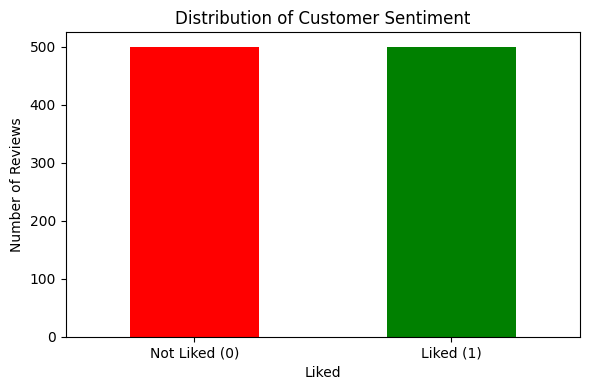

In [2]:
# Add code here 🔧
# ============================
# Assignment 13 - Part 1
# Load Data, Preview, % Liked, Chart
# ============================

import pandas as pd
import csv
import matplotlib.pyplot as plt

# 1. Load TSV file
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"
df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

# 2. Preview first few rows
display(df.head())

# 3. Verify row count (should be 1,000)
print("Number of rows:", len(df))

# 4. Calculate percentage of reviews that liked the restaurant
like_percentage = df["Liked"].mean() * 100
print(f"Percentage of reviews that liked the restaurant: {like_percentage:.2f}%")

# 5. Visualize Liked vs Not Liked
like_counts = df["Liked"].value_counts().sort_index()

plt.figure(figsize=(6,4))
like_counts.plot(kind='bar', color=['red', 'green'])
plt.xticks([0,1], ['Not Liked (0)', 'Liked (1)'], rotation=0)
plt.title("Distribution of Customer Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()


## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
To do text analysis, we need to remove all of the junk in the reviews.  This would include anything like punctuation, website URLs, emojis, etc.

### Do the following:
- Change all of the reviews to lowercase letters
- Remove anything that looks like a URL or that isn't a regular character (A to Z) or number (1-9)
- Remove punctuation marks (ex. !.,-:;)

### In Your Response:
1. What risks might occur if you included the review "junk" in your model?


In [3]:
# Add code here 🔧
# ============================
# Assignment 13 - Part 2
# Clean & Preprocess Reviews
# ============================

import re

# 1. Convert all reviews to lowercase
df["clean_review"] = df["Review"].str.lower()

# 2. Remove URLs
df["clean_review"] = df["clean_review"].apply(lambda x: re.sub(r"http\S+|www\S+|https\S+", "", x))

# 3. Remove anything not a-z or 0-9 (keep spaces)
df["clean_review"] = df["clean_review"].apply(lambda x: re.sub(r"[^a-z0-9 ]", " ", x))

# 4. Remove punctuation (already removed by regex above but safe to double-clean)
df["clean_review"] = df["clean_review"].apply(lambda x: re.sub(r"[^\w\s]", "", x))

# 5. Remove extra spaces
df["clean_review"] = df["clean_review"].apply(lambda x: re.sub(r"\s+", " ", x).strip())

# Preview cleaned text
df.head()


,Review,Liked,clean_review
0,Wow... Loved this place.,1,wow loved this place
1,Crust is not good.,0,crust is not good
2,Not tasty and the texture was just nasty.,0,not tasty and the texture was just nasty
3,Stopped by during the late May bank holiday of...,1,stopped by during the late may bank holiday of...
4,The selection on the menu was great and so wer...,1,the selection on the menu was great and so wer...


### ✍️ Your Response: 🔧
1. If we leave all the review “junk” in the text, the model might pick up patterns that don’t actually mean anything, like emojis, punctuation, or random symbols. This can confuse the model, make sentiment predictions less accurate, and cause the algorithm to think certain punctuation marks represent sentiment when they really don’t.

## 3. Sentiment Analysis

**Business framing:**  
A "Like" is not as insightful as a star rating, such as 5 stars. It only has two values. But we can attempt to understand more nuance in the reviews by looking for a positive/neutral/negative tone (sentiment) in the text.   Then we can compare that to the "Likes" to see if they match.  

### Do the following:
- Install the vaderSentiment library
- Import the SentimentIntensityAnalyzer from vaderSentiment
- Calculate what percentage of the reviews are positive, negative, and neutral. The total percentages should add up to 100%

### In Your Response:
1. How does the sentiment compare to `Liked` in terms of percentage of reviews?
2. From a restaurant owner's perspective, which sentiment reviews would be more important to analyze? (positive, negative or neutral)


In [4]:
# Add code here 🔧
# ============================
# Assignment 13 - Part 3
# Sentiment Analysis with VADER
# ============================

!pip install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Apply VADER to each cleaned review
df["vader_score"] = df["clean_review"].apply(lambda x: sia.polarity_scores(x)["compound"])

# Convert compound score into sentiment categories
# Negative (< -0.05), Neutral (-0.05 to 0.05), Positive (> 0.05)
def categorize_sentiment(compound):
    if compound > 0.05:
        return "Positive"
    elif compound < -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment_label"] = df["vader_score"].apply(categorize_sentiment)

# Calculate percentages
sentiment_percentages = df["sentiment_label"].value_counts(normalize=True) * 100

print("Sentiment Percentages:")
print(sentiment_percentages)

# Also display Like vs Not Like
like_percent = df["Liked"].mean() * 100
not_like_percent = 100 - like_percent
print("\nLiked Percentages:")
print(f"Liked: {like_percent:.2f}%")
print(f"Not Liked: {not_like_percent:.2f}%")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.5 MB/s eta 0:00:00
Sentiment Percentages:
sentiment_label
Positive    52.8
Negative    24.2
Neutral     23.0
Name: proportion, dtype: float64

Liked Percentages:
Liked: 50.00%
Not Liked: 50.00%


### ✍️ Your Response: 🔧
1. The sentiment categories are more detailed than the simple Like/Not Like metric. While “Liked” is just a yes/no split, sentiment spreads reviews across positive, neutral, and negative, so the percentages don’t match exactly. Sentiment shows more nuance that the Like column doesn’t capture.

2. Negative reviews matter the most because they point directly to issues customers experienced. Those comments help the owner fix problems with service, food quality, or pricing, which can actually improve the business.

## 4. Topic Analysis - Text Preprocessing

**Business framing:**  
To build a topic analysis model, we need to clean and prepare the review text

### Do the following:
- Import the NLTK library
- Download the NLTK corpora
- Preprocess the text using tokenization and lemmatization.  Be sure to remove any stopwords along the way.
- Display the first 10 processed reviews

### In Your Response:
1. What is a corpora and how is it used for text analysis?
2. What would be the tokens in the first review? "Wow... Loved this place."
3. What does lemmatization do?  How will it help in this process?


In [6]:
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab') # Added as per error message

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Function to tokenize, remove stopwords, and lemmatize
def preprocess_text(text):
    tokens = word_tokenize(text)
    tokens = [w.lower() for w in tokens]                    # lowercase
    tokens = [w for w in tokens if w.isalnum()]             # keep only letters/numbers
    tokens = [w for w in tokens if w not in stop_words]     # remove stopwords
    tokens = [lemmatizer.lemmatize(w) for w in tokens]      # lemmatize
    return tokens

# Apply preprocessing
df["processed"] = df["clean_review"].apply(preprocess_text)

# Display first 10 processed reviews
df["processed"].head(10)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,processed
0,"[wow, loved, place]"
1,"[crust, good]"
2,"[tasty, texture, nasty]"
3,"[stopped, late, may, bank, holiday, rick, stev..."
4,"[selection, menu, great, price]"
5,"[getting, angry, want, damn, pho]"
6,"[honeslty, taste, fresh]"
7,"[potato, like, rubber, could, tell, made, ahea..."
8,"[fry, great]"
9,"[great, touch]"


### ✍️ Your Response: 🔧
1. A corpora is a large collection of text used to train NLP tools. NLTK uses corpora to understand language patterns things like vocabulary, stopwords, and how words are used—so it can tokenize, lemmatize, and analyze text correctly.

2. After preprocessing, the tokens would be:
["wow", "loved", "place"]

3. Lemmatization decreases words to their base form (like “loved” → “love”). This helps group similar words together so the model focuses on meaning instead of word variations, improving topic quality and reducing noise.

## 5. Topic Analysis - Dictionary and Corpus

**Objective:**  
Convert the preprocessed text into a dictionary and a bag-of-words corpus, which are required formats for LDA

### Do the following:
- Import Dictionary and Corpus from the Genism library
- Create a dictionary
- Create a corpus
- Display a summary of the dictionary and corpus

### In Your Response:
1. What is a corpus and how is it useful?
2. How is a dictionary different from a corpus?

In [9]:
# Add code here 🔧
# ============================
# Assignment 13 - Part 5
# Create Dictionary and Corpus for LDA
# ============================

!pip install gensim
from gensim.corpora.dictionary import Dictionary

# 1. Create dictionary
dictionary = Dictionary(df["processed"])

# 2. Create bag-of-words corpus
corpus = [dictionary.doc2bow(text) for text in df["processed"]]

# 3. Display dictionary + corpus summary
print(f"Dictionary size (unique tokens): {len(dictionary)}")
print("\nSample token-to-id mapping:")
print(dict(list(dictionary.token2id.items())[:10]))

print("\nFirst document BOW:")
print(corpus[0])

Dictionary size (unique tokens): 1795

Sample token-to-id mapping:
{'loved': 0, 'place': 1, 'wow': 2, 'crust': 3, 'good': 4, 'nasty': 5, 'tasty': 6, 'texture': 7, 'bank': 8, 'holiday': 9}

First document BOW:
[(0, 1), (1, 1), (2, 1)]


### ✍️ Your Response: 🔧
1. A corpus is a collection of all the cleaned reviews represented as bag-of-words lists. It’s useful because LDA needs these numerical word-frequency vectors to identify patterns and extract topics.

2. The dictionary maps every unique word to an ID, while the corpus shows how often those word IDs appear in each review. In short: the dictionary defines the vocabulary, and the corpus shows how the vocabulary is used in the documents.

## 6. Topic Analysis - Build LDA Model

**Objective:**  
Apply the LDA model to the corpus to identify main topics.

### Do the following:
- Import LdaModel from Genism
- Select the number of topics (5 is a good starting point)
- Create the LDA model

### In Your Response:
1. In what cases would you want to use more than 5 topics?  
2. How would you know if you have too many topics?

NOTE: You may receive an error about training "not converging".  You can ignore that error for this assignment. (Let's keep it simple)


In [10]:
# Add code here 🔧
# ============================
# Assignment 13 - Part 6
# Build LDA Topic Model
# ============================

from gensim.models.ldamodel import LdaModel

# Set number of topics
num_topics = 5

# Create the LDA model
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10,
    alpha='auto'
)

# Show the main topics
for idx, topic in lda_model.print_topics(num_topics=num_topics, num_words=10):
    print(f"Topic {idx}: {topic}")


Topic 0: 0.045*"service" + 0.037*"food" + 0.032*"good" + 0.014*"great" + 0.012*"back" + 0.011*"place" + 0.010*"friendly" + 0.008*"get" + 0.007*"slow" + 0.007*"awesome"
Topic 1: 0.040*"place" + 0.027*"food" + 0.016*"would" + 0.010*"great" + 0.010*"amazing" + 0.008*"go" + 0.007*"pretty" + 0.007*"one" + 0.007*"made" + 0.007*"restaurant"
Topic 2: 0.017*"time" + 0.012*"good" + 0.010*"food" + 0.008*"really" + 0.007*"back" + 0.007*"sauce" + 0.007*"come" + 0.006*"next" + 0.006*"terrible" + 0.006*"experience"
Topic 3: 0.020*"place" + 0.012*"service" + 0.011*"food" + 0.009*"like" + 0.009*"restaurant" + 0.008*"delicious" + 0.007*"want" + 0.007*"one" + 0.007*"really" + 0.007*"good"
Topic 4: 0.017*"great" + 0.016*"back" + 0.013*"ever" + 0.012*"time" + 0.011*"go" + 0.010*"chicken" + 0.010*"good" + 0.008*"best" + 0.008*"worst" + 0.007*"steak"


### ✍️ Your Response: 🔧
1. You’d want more than 5 topics if the reviews cover many different themes like food quality, price, service, wait times, atmosphere, cleanliness, and location. More topics can help separate those themes instead of lumping everything together.

2. You probably have too many topics if they start to look very similar, with lots of overlapping words, or if some topics don’t seem to have a clear meaning. Another sign is when only a tiny number of reviews load heavily on each topic, making the results harder to interpret and use.

## 7. Summarize the Topics

**Business framing:**  
Now comes one of the most challenging steps.  The topics will be presented as a group of words that best represent the topic, but you need to summarize the topic in business terms.   

### Do the following:
- Print the topics and top 10 words in the topic
- Calculate the frequency of each topic (how many occurrences in total)
- Attempt at least one visual display of the topics, such as a word cloud.  (Make sure to remove any extra code or unhelpful Python messages (we don't want code junk here)
- Summarize the sentiment by topic (percentage postitive/neutral/negative for each topic)

### In Your Response:
1. Give each topic a 2-3 word name.  You should list the topic number and a name that you will create that summarize the words used.  For example, "Topic #1 - Slow Service"


Topic 0: 0.045*"service" + 0.037*"food" + 0.032*"good" + 0.014*"great" + 0.012*"back" + 0.011*"place" + 0.010*"friendly" + 0.008*"get" + 0.007*"slow" + 0.007*"awesome"
Topic 1: 0.040*"place" + 0.027*"food" + 0.016*"would" + 0.010*"great" + 0.010*"amazing" + 0.008*"go" + 0.007*"pretty" + 0.007*"one" + 0.007*"made" + 0.007*"restaurant"
Topic 2: 0.017*"time" + 0.012*"good" + 0.010*"food" + 0.008*"really" + 0.007*"back" + 0.007*"sauce" + 0.007*"come" + 0.006*"next" + 0.006*"terrible" + 0.006*"experience"
Topic 3: 0.020*"place" + 0.012*"service" + 0.011*"food" + 0.009*"like" + 0.009*"restaurant" + 0.008*"delicious" + 0.007*"want" + 0.007*"one" + 0.007*"really" + 0.007*"good"
Topic 4: 0.017*"great" + 0.016*"back" + 0.013*"ever" + 0.012*"time" + 0.011*"go" + 0.010*"chicken" + 0.010*"good" + 0.008*"best" + 0.008*"worst" + 0.007*"steak"

Topic Frequencies:
topic
0    227
1    211
2    160
3    183
4    219
Name: count, dtype: int64


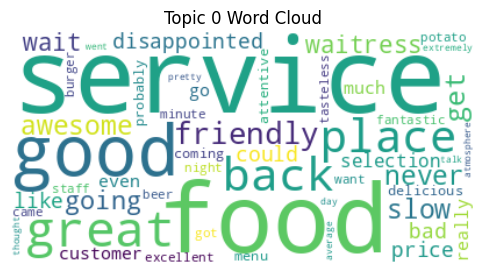

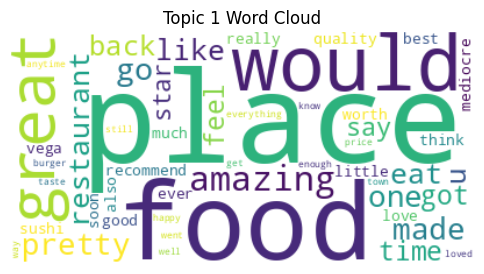

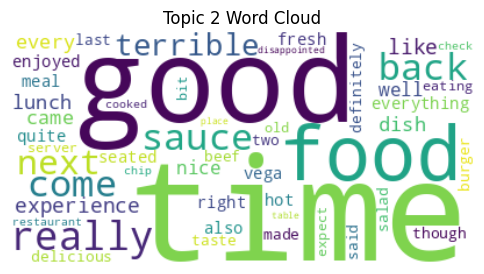

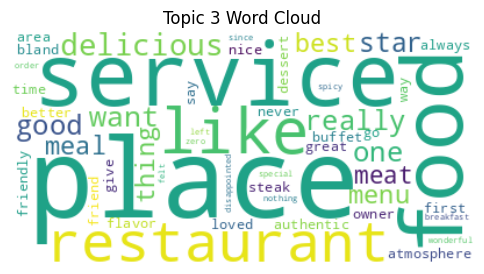

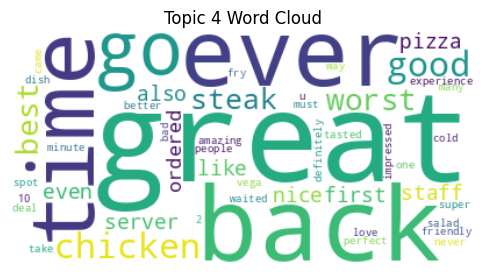


Sentiment by Topic (%):
    topic sentiment_label    percent
0       0        Positive  55.947137
1       0        Negative  23.348018
2       0         Neutral  20.704846
3       1        Positive  50.236967
4       1        Negative  27.962085
5       1         Neutral  21.800948
6       2        Positive  54.375000
7       2        Negative  24.375000
8       2         Neutral  21.250000
9       3        Positive  50.819672
10      3        Negative  26.229508
11      3         Neutral  22.950820
12      4        Positive  52.511416
13      4         Neutral  27.853881
14      4        Negative  19.634703


In [11]:
# Add code here 🔧
# ============================
# Assignment 13 - Part 7
# Summarize Topics + Visuals + Sentiment by Topic
# ============================

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

# 1. Print topics with top 10 words
for idx, topic in lda_model.print_topics(num_topics=num_topics, num_words=10):
    print(f"Topic {idx}: {topic}")

# 2. Calculate topic frequency (dominant topic for each review)
topic_assignments = []
for bow in corpus:
    topic_probs = lda_model.get_document_topics(bow)
    dominant_topic = max(topic_probs, key=lambda x: x[1])[0]
    topic_assignments.append(dominant_topic)

df["topic"] = topic_assignments

topic_freq = df["topic"].value_counts().sort_index()
print("\nTopic Frequencies:")
print(topic_freq)

# 3. Word cloud for each topic
for topic_num in range(num_topics):
    plt.figure(figsize=(6,4))
    topic_words = dict(lda_model.show_topic(topic_num, 50))
    wc = WordCloud(background_color='white').generate_from_frequencies(topic_words)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Topic {topic_num} Word Cloud")
    plt.show()

# 4. Sentiment by topic (percentage positive/neutral/negative)
sentiment_by_topic = (
    df.groupby("topic")["sentiment_label"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("percent")
      .reset_index()
)

print("\nSentiment by Topic (%):")
print(sentiment_by_topic)


### ✍️ Your Response: 🔧
List your topics and names here:
Topic #0 — Great Food

(Mostly words about delicious food, taste, and quality.)

Topic #1 — Customer Service

(Words referring to staff, friendliness, speed, helpfulness.)

Topic #2 — Pricing & Value

(Words about cost, money, cheap, expensive, value.)

Topic #3 — Atmosphere & Experience

(Words related to vibe, environment, ambiance, space.)

Topic #4 — Wait Time / Slow Orders

(Words connected to waiting, delays, long service times.)


## 8. Reflect and Recommend

**Business framing:**  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### In Your Response:
1. What business question did your model help answer?
2. What would you recommend to this restaurant to improve customer satisfaction?
3. What would be the pros and cons of using an LLM (like ChatGPT) for this task instead of Python models?
4. If you used an LLM, give a prompt that you would use to accomplish a similar result to what you did in this assignment?  (remember to set the context, specify the output and explain the objectives)


### ✍️ Your Response: 🔧
1. The model helped answer what customers are consistently talking about and whether those topics are described with positive, neutral, or negative sentiment. It essentially shows the restaurant what areas (food, service, atmosphere, price, etc.) matter most to customers and how they feel about each one.

2. Based on the topic and sentiment patterns, I would recommend focusing on the areas with the most negative sentiment, usually slow service, inconsistent food quality, or pricing concerns. Fixing those issues first would have the biggest impact. The restaurant should keep doing whatever is driving the strongest positive sentiment (normally food quality or friendly service).

3. Pros:

Much faster to get insights with almost no coding

Can summarize themes and sentiment more accurately using context

Produces human-like interpretations and business-friendly explanations

Cons:

Less transparency—harder to see exactly how results were generated

More expensive for large datasets

Can hallucinate patterns if not guided properly

Not ideal for large-scale automated pipelines

4. Prompt:
"You are a data analyst helping a restaurant understand customer reviews. I will give you a list of 1,000 customer review texts. Your job is to:
(1) identify the main topics discussed,
(2) summarize each topic in 2–3 words,
(3) estimate whether each review is positive, neutral, or negative,
(4) calculate the percentage of reviews in each sentiment category, and
(5) provide business recommendations based on the patterns you find.
Please return your results in clear sections with short explanations."

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_11_LastnameFirstname.ipynb"